In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay, confusion_matrix,f1_score, accuracy_score)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

## Loading Data

In [3]:
df = pd.read_csv('../data/processed/station2_labelled.csv')

FEATURES = [
    'DO', 'PH', 'AMMONIA(mg/l)', 'TEMP', 'NITRATE(PPM)', 'TURBIDITY',
]
TARGET      = 'feed_label'
CLASS_NAMES = ['Prime Feed', 'Reduce Feed', 'Halt Feeding']

##  Spliting Data

In [4]:
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y
)

## Preprocessing with SMOTE (training set only)

In [5]:
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X_train, y_train)

In [6]:
print(f"berfore smote: {X_train.shape} ")
print(f"after smote: {X_bal.shape}")

berfore smote: (20343, 6) 
after smote: (23694, 6)


## Defining Base model for training

In [7]:
models = {

    'Decision Tree': DecisionTreeClassifier(
        max_depth        = 10,
        min_samples_leaf = 10,
        class_weight     = 'balanced',
        random_state     = 42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators     = 300,
        max_depth        = 12,
        min_samples_leaf = 5,
        max_features     = 'sqrt',
        class_weight     = 'balanced',
        random_state     = 42,
        n_jobs           = -1
    ),

    'XGBoost': XGBClassifier(
        n_estimators      = 300,
        max_depth         = 6,
        learning_rate     = 0.05,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        min_child_weight  = 5,
        eval_metric       = 'mlogloss',
        random_state      = 42,
        n_jobs            = -1
    ),

    # 'LightGBM': LGBMClassifier(
    #     n_estimators      = 300,
    #     max_depth         = 6,
    #     learning_rate     = 0.05,
    #     subsample         = 0.8,
    #     colsample_bytree  = 0.8,
    #     min_child_samples = 20,
    #     random_state      = 42,
    #     n_jobs            = -1,
    #     verbose           = -1
    # ),
}

## Cross Validation Our models

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    pipe = Pipeline([('smote', SMOTE(random_state=42)), ('clf', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro')
    print(f'{name}: CV F1_macro = {scores.mean():.4f} (+/- {scores.std():.4f})')

Decision Tree: CV F1_macro = 0.9890 (+/- 0.0016)
Random Forest: CV F1_macro = 0.9904 (+/- 0.0015)
XGBoost: CV F1_macro = 0.9898 (+/- 0.0026)


## Train On Full Balanced Traiing Set

In [9]:
results = {}

for name, model in models.items():
    model.fit(X_bal, y_bal)
    y_pred = model.predict(X_test)
    
    results[name] = {
        'model'       : model,
        'y_pred'      : y_pred,
        'f1_macro'    : f1_score(y_test, y_pred, average='macro'),
        'f1_weighted' : f1_score(y_test, y_pred, average='weighted'),
        'accuracy'    : accuracy_score(y_test, y_pred),
        'f1_per_class': f1_score(y_test, y_pred, average=None, labels=[0,1,2]),
    }

In [10]:
results

{'Decision Tree': {'model': DecisionTreeClassifier(class_weight='balanced', max_depth=10,
                         min_samples_leaf=10, random_state=42),
  'y_pred': array([2, 1, 0, ..., 0, 0, 1], shape=(5086,)),
  'f1_macro': 0.9912960692399596,
  'f1_weighted': 0.992134755727203,
  'accuracy': 0.9921352732992529,
  'f1_per_class': array([0.99195115, 0.98472116, 0.99721589])},
 'Random Forest': {'model': RandomForestClassifier(class_weight='balanced', max_depth=12,
                         min_samples_leaf=5, n_estimators=300, n_jobs=-1,
                         random_state=42),
  'y_pred': array([2, 1, 0, ..., 0, 0, 1], shape=(5086,)),
  'f1_macro': 0.9910851550175964,
  'f1_weighted': 0.9919323460461589,
  'accuracy': 0.9919386551317342,
  'f1_per_class': array([0.9922179 , 0.98432122, 0.99671634])},
 'XGBoost': {'model': XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=0.8, 

## Evaluating

In [11]:
for name, r in results.items():
    f = r['f1_per_class']
    print(f"{name}: Acc={r['accuracy']:.4f}  F1={r['f1_macro']:.4f}  "
          f"Prime={f[0]:.4f}  Reduce={f[1]:.4f}  Halt={f[2]:.4f}")

best_name = max(results, key=lambda k: results[k]['f1_macro'])
best      = results[best_name]

print(f'\nBest: {best_name}')
print(classification_report(y_test, best['y_pred'],
      target_names=CLASS_NAMES, digits=4))

Decision Tree: Acc=0.9921  F1=0.9913  Prime=0.9920  Reduce=0.9847  Halt=0.9972
Random Forest: Acc=0.9919  F1=0.9911  Prime=0.9922  Reduce=0.9843  Halt=0.9967
XGBoost: Acc=0.9947  F1=0.9941  Prime=0.9928  Reduce=0.9897  Halt=0.9997

Best: XGBoost
              precision    recall  f1-score   support

  Prime Feed     0.9961    0.9895    0.9928      1802
 Reduce Feed     0.9856    0.9939    0.9897      1309
Halt Feeding     0.9995    1.0000    0.9997      1975

    accuracy                         0.9947      5086
   macro avg     0.9937    0.9944    0.9941      5086
weighted avg     0.9947    0.9947    0.9947      5086



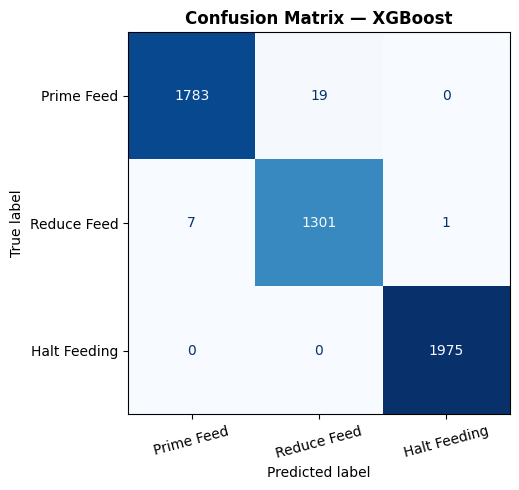

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, best['y_pred']),
    display_labels=CLASS_NAMES
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=12, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')

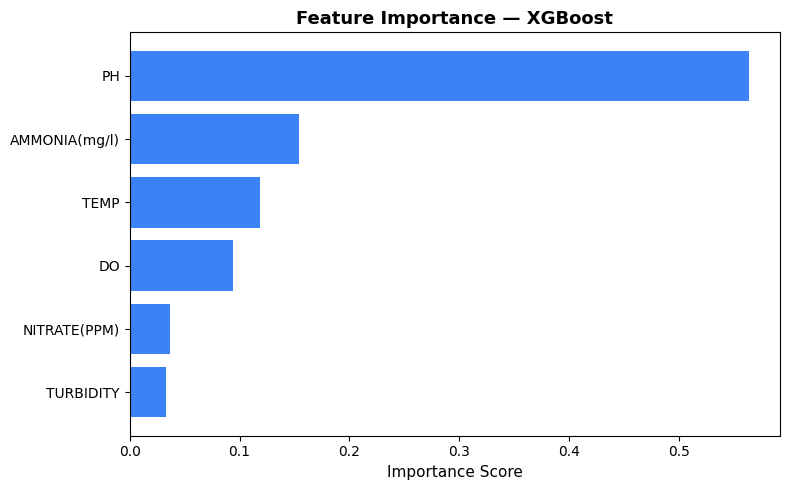

In [14]:
fi = pd.Series(
    best['model'].feature_importances_,
    index=FEATURES
).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(fi.index, fi.values, color='#3b82f6')
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title(f'Feature Importance — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

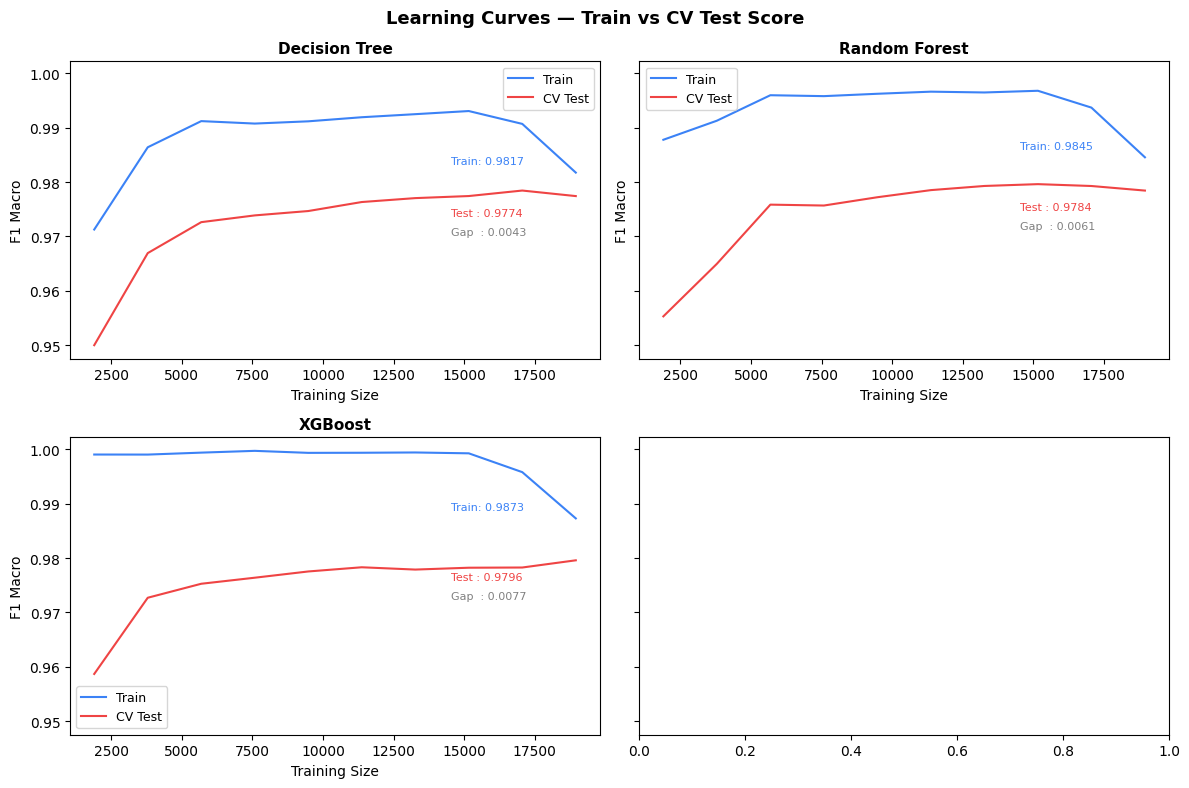

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)

for ax, (name, r) in zip(axes.flatten(), results.items()):
    train_sizes, train_scores, test_scores = learning_curve(
        r['model'], X_bal, y_bal,
        cv=5, scoring='f1_macro',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    test_mean  = test_scores.mean(axis=1)
    gap        = train_mean - test_mean

    ax.plot(train_sizes, train_mean, label='Train',   color='#3b82f6')
    ax.plot(train_sizes, test_mean,  label='CV Test', color='#ef4444')

    # Annotate final scores and gap at the last training size
    ax.annotate(f'Train: {train_mean[-1]:.4f}',
                xy=(train_sizes[-1], train_mean[-1]),
                xytext=(-90, 6), textcoords='offset points', fontsize=8, color='#3b82f6')
    ax.annotate(f'Test : {test_mean[-1]:.4f}',
                xy=(train_sizes[-1], test_mean[-1]),
                xytext=(-90, -14), textcoords='offset points', fontsize=8, color='#ef4444')
    ax.annotate(f'Gap  : {gap[-1]:.4f}',
                xy=(train_sizes[-1], test_mean[-1]),
                xytext=(-90, -28), textcoords='offset points', fontsize=8, color='gray')

    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Training Size')
    ax.set_ylabel('F1 Macro')
    ax.legend(fontsize=9)

plt.suptitle('Learning Curves — Train vs CV Test Score', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()